# B2 - Full AlphaZero on tic-tac-toe, verified against minimax

Now the whole loop (`azl.trainer.Coach`):
**self-play -> store (state, MCTS-policy, outcome) -> train policy+value -> repeat.**

Tic-tac-toe is *solved*, so unlike raccoon we have **ground truth**: after each few
iterations we ask "what fraction of positions does the agent play optimally?" and
"does it still lose to perfect play?". This is the verifiable signal that the whole
thing actually works.

In [1]:
import numpy as np, torch
import matplotlib.pyplot as plt
from azl.games.tictactoe import TicTacToe
from azl.network import net_for_game
from azl.trainer import Coach, CoachConfig
from azl.solvers import ExactSolver, enumerate_states
from azl.evaluate import mcts_player, play_match, random_player, solver_player
from azl.metrics import optimal_action_accuracy

torch.manual_seed(0)
solver = ExactSolver()
# A fixed sample of positions to grade on.
all_states = enumerate_states(TicTacToe.start())
grade_states = [all_states[i] for i in np.random.default_rng(0).choice(len(all_states), 250, replace=False)]

In [2]:
net = net_for_game(TicTacToe)
cfg = CoachConfig(games_per_iter=18, num_simulations=48, temp_threshold=3, training_steps=40)
coach = Coach(net=net, game_cls=TicTacToe, config=cfg, seed=0)

acc_hist, iters = [], []
def grade(i, metrics, coach):
    if i % 3: return
    play = mcts_player(coach.net, num_simulations=48, rng=np.random.default_rng(i))
    acc = optimal_action_accuracy(play, grade_states, solver)
    acc_hist.append(acc); iters.append(i)
    print(f"    [grade] iter {i}: optimal-move accuracy = {acc:.3f}")

coach.train(24, callback=grade)

iter   1  policy 2.097  value 0.456  entropy 1.355  moves 8.1  p0_ret +0.17  (2.08s)


iter   2  policy 1.921  value 0.241  entropy 1.289  moves 7.0  p0_ret +0.39  (1.94s)


    [grade] iter 3: optimal-move accuracy = 0.936
iter   3  policy 1.711  value 0.231  entropy 1.200  moves 7.0  p0_ret +0.44  (1.87s)


iter   4  policy 1.556  value 0.216  entropy 1.097  moves 7.1  p0_ret +0.72  (1.93s)


iter   5  policy 1.422  value 0.209  entropy 0.952  moves 8.1  p0_ret +0.28  (1.98s)


...

    [grade] iter 21: optimal-move accuracy = 0.948
iter  21  policy 0.925  value 0.116  entropy 0.678  moves 8.9  p0_ret +0.06  (2.22s)


iter  22  policy 0.919  value 0.112  entropy 0.721  moves 8.8  p0_ret +0.11  (2.16s)


iter  23  policy 0.897  value 0.109  entropy 0.643  moves 8.9  p0_ret +0.06  (1.92s)


    [grade] iter 24: optimal-move accuracy = 0.944
iter  24  policy 0.915  value 0.110  entropy 0.677  moves 9.0  p0_ret +0.00  (1.95s)


[{'policy_loss': 2.0974971681833265,
  'value_loss': 0.4562242679297924,
  'iteration': 1,
  'buffer': 146,
  'avg_moves': 8.11111111111111,
  'avg_visit_entropy': 1.354965294501603,
  'p0_return': 0.16666666666666666,
  'seconds': 2.08},
 {'policy_loss': 1.9206398963928222,
  'value_loss': 0.2413385570049286,
  'iteration': 2,
  'buffer': 272,
  'avg_moves': 7.0,
  'avg_visit_entropy': 1.2890828499385971,
  'p0_return': 0.3888888888888889,
  'seconds': 1.94},
 {'policy_loss': 1.7112606793642045,
  'value_loss': 0.23126371577382088,
  'iteration': 3,
  'buffer': 398,
  'avg_moves': 7.0,
  'avg_visit_entropy': 1.199869882585138,
  'p0_return': 0.4444444444444444,
  'seconds': 1.87},
 {'policy_loss': 1.55636385679245,
  'value_loss': 0.21554783508181571,
  'iteration': 4,
  'buffer': 526,
  'avg_moves': 7.111111111111111,
  'avg_visit_entropy': 1.097399615152773,
  'p0_return': 0.7222222222222222,
  'seconds': 1.93},
 {'policy_loss': 1.4216535627841949,
  'value_loss': 0.2091039951890707

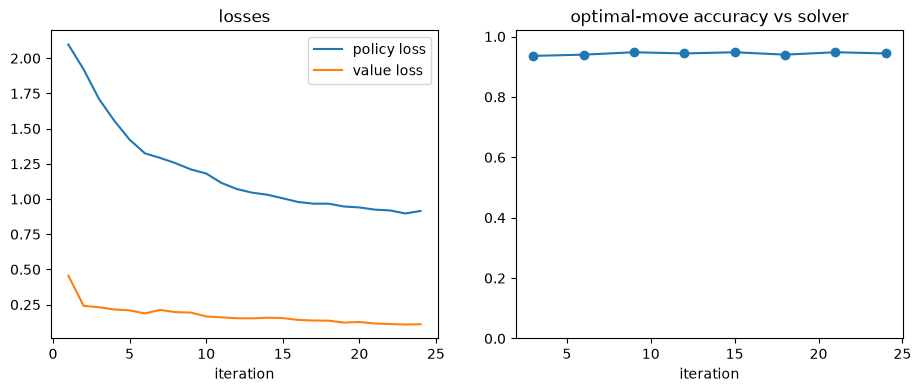

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
hist = coach.history
ax[0].plot([h["iteration"] for h in hist], [h["policy_loss"] for h in hist], label="policy loss")
ax[0].plot([h["iteration"] for h in hist], [h["value_loss"] for h in hist], label="value loss")
ax[0].set_xlabel("iteration"); ax[0].legend(); ax[0].set_title("losses")
ax[1].plot(iters, acc_hist, "o-"); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("iteration"); ax[1].set_title("optimal-move accuracy vs solver"); plt.show()

In [4]:
# The headline check: how does it do against PERFECT play and against random?
rng = np.random.default_rng(1)
vs_solver = play_match(TicTacToe, mcts_player(net, 100, rng=rng), solver_player(solver, rng), num_games=100, rng=rng)
vs_random = play_match(TicTacToe, mcts_player(net, 100, rng=rng), random_player(rng), num_games=100, rng=rng)
print("vs perfect play:", vs_solver, "  <- losses should be near 0 (perfect play can only draw)")
print("vs random      :", vs_random)

vs perfect play: {'num_games': 100, 'a_wins': 0, 'draws': 88, 'a_losses': 12, 'a_return_mean': -0.12}   <- losses should be near 0 (perfect play can only draw)
vs random      : {'num_games': 100, 'a_wins': 97, 'draws': 3, 'a_losses': 0, 'a_return_mean': 0.97}


### What to notice
- **Optimal-move accuracy climbs** to ~0.95 and the agent **draws the great majority
  of games against perfect play and never beats it** (perfect play can't be beaten) -
  it has essentially learned the game from self-play alone. The handful of remaining
  losses shrink as you add iterations or search (raise `--simulations`).
- **`p0_return` drifts from positive toward 0** (printed each iter): early on the
  first player exploits weak play; as both sides sharpen, games become draws.
- **Value loss keeps falling, yet the value head grows blind to off-distribution
  positions.** Once self-play only produces draws, "everything looks like 0", so it
  forgets that many positions are theoretically won or lost. That's **distributional
  poverty** - the pathology raccoon documents in backgammon, reproduced here in
  seconds (B5 measures this gap to the solver explicitly).

### Maps to raccoon
`Coach.run_iteration` here mirrors raccoon's. The loss `CE(policy)+MSE(value)` is
identical. The difference: raccoon can only *estimate* progress via GNUBG, while we
read it straight off the solver.